In [1]:
#importação de bibliotecas 
import geopandas as gpd
import matplotlib.pyplot as plt 
import pandas as pd

   Id  OBJECTID_1  VALUE   COUNT      AREA       MIN       MAX     RANGE  \
0   0           1      0  4328.0  1.609425  0.178378  0.739130  0.560752   
1   0           2      1  3076.0  1.143852  0.037736  0.734177  0.696441   
2   0           3      2  1320.0  0.490860  0.024000  0.664804  0.640804   
3   0           4      3  2982.0  1.108897 -0.123894  0.727273  0.851167   
4   0           5      4  4485.0  1.667808  0.234043  0.728814  0.494771   

       MEAN       STD          SUM    MEDIAN     PCT90  \
0  0.567456  0.074824  2455.951652  0.574564  0.656151   
1  0.557378  0.102124  1714.495059  0.577936  0.670886   
2  0.475613  0.099797   627.809022  0.494317  0.581395   
3  0.495354  0.108096  1477.145040  0.518987  0.600000   
4  0.572624  0.077642  2568.217152  0.585859  0.661972   

                                            geometry  
0  POLYGON ((475503.8 4323511.185, 475504.198 432...  
1  POLYGON ((475510.748 4323498.654, 475511.306 4...  
2  POLYGON ((475509.211 43234

<Axes: >

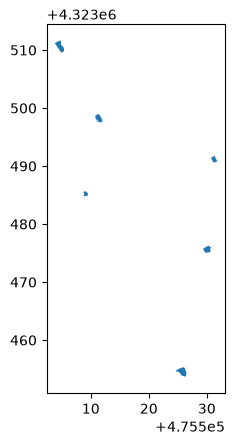

In [2]:
#Ler ficheiros shapfile 
dados = gpd.read_file("Data_vegetacao_ex_stats.zip")

#Mostrar dados do ficheiro
print(dados.head())

#Mostrar dados visuais (mapa)
dados.plot()

In [3]:
#Renomear algumas colunas das tabelas 
dados.rename(columns={
    "OBJECTID_1": "zone_id",
    "COUNT": "count_value",
    "AREA": "area",
    "MIN": "min_value",
    "MAX": "max_value",
    "MEAN": "mean_value",
    "RANGE": "range_value",
    "MEDIAN": "median_value",
    "STD": "std_value",
    "PCT90": "pct90_value",
    "SUM": "sum_value"
}, inplace=True)

print(dados.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            6 non-null      int32   
 1   zone_id       6 non-null      int32   
 2   VALUE         6 non-null      int64   
 3   count_value   6 non-null      float64 
 4   area          6 non-null      float64 
 5   min_value     6 non-null      float64 
 6   max_value     6 non-null      float64 
 7   range_value   6 non-null      float64 
 8   mean_value    6 non-null      float64 
 9   std_value     6 non-null      float64 
 10  sum_value     6 non-null      float64 
 11  median_value  6 non-null      float64 
 12  pct90_value   6 non-null      float64 
 13  geometry      6 non-null      geometry
dtypes: float64(10), geometry(1), int32(2), int64(1)
memory usage: 756.0 bytes
None


In [4]:
#Inserir novas colunas a tabela 
dados.insert(0, "raw_id", range(1,len(dados) + 1))
dados.insert(12,"loaded_at", "")
dados.insert(13, "source_file", "raw_vegetatiion_stats.csv")

#Mostrar os dados da tabela 
print(dados.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   raw_id        6 non-null      int64   
 1   Id            6 non-null      int32   
 2   zone_id       6 non-null      int32   
 3   VALUE         6 non-null      int64   
 4   count_value   6 non-null      float64 
 5   area          6 non-null      float64 
 6   min_value     6 non-null      float64 
 7   max_value     6 non-null      float64 
 8   range_value   6 non-null      float64 
 9   mean_value    6 non-null      float64 
 10  std_value     6 non-null      float64 
 11  sum_value     6 non-null      float64 
 12  loaded_at     6 non-null      str     
 13  source_file   6 non-null      str     
 14  median_value  6 non-null      float64 
 15  pct90_value   6 non-null      float64 
 16  geometry      6 non-null      geometry
dtypes: float64(10), geometry(1), int32(2), int64(2), s

In [5]:
#Retirar colunas 
dados = dados.drop(columns= ["Id", "VALUE"])

#Mostrar resultado 
print(dados.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   raw_id        6 non-null      int64   
 1   zone_id       6 non-null      int32   
 2   count_value   6 non-null      float64 
 3   area          6 non-null      float64 
 4   min_value     6 non-null      float64 
 5   max_value     6 non-null      float64 
 6   range_value   6 non-null      float64 
 7   mean_value    6 non-null      float64 
 8   std_value     6 non-null      float64 
 9   sum_value     6 non-null      float64 
 10  loaded_at     6 non-null      str     
 11  source_file   6 non-null      str     
 12  median_value  6 non-null      float64 
 13  pct90_value   6 non-null      float64 
 14  geometry      6 non-null      geometry
dtypes: float64(10), geometry(1), int32(1), int64(1), str(2)
memory usage: 828.0 bytes
None


In [6]:
#Ordenar colunas 
dados_ordem = ["raw_id",  
               "zone_id", 
               "count_value", 
               "area", 
               "min_value", 
               "max_value", 
               "mean_value", 
               "median_value", 
               "std_value", 
               "pct90_value", 
               "sum_value", 
               "range_value",
               "geometry",
               "loaded_at",
               "source_file"
              ]
#aplicar a ordem na tabela 
dados = dados[dados_ordem]

#Mostrar resultados 
print(dados.head())

   raw_id  zone_id  count_value      area  min_value  max_value  mean_value  \
0       1        1       4328.0  1.609425   0.178378   0.739130    0.567456   
1       2        2       3076.0  1.143852   0.037736   0.734177    0.557378   
2       3        3       1320.0  0.490860   0.024000   0.664804    0.475613   
3       4        4       2982.0  1.108897  -0.123894   0.727273    0.495354   
4       5        5       4485.0  1.667808   0.234043   0.728814    0.572624   

   median_value  std_value  pct90_value    sum_value  range_value  \
0      0.574564   0.074824     0.656151  2455.951652     0.560752   
1      0.577936   0.102124     0.670886  1714.495059     0.696441   
2      0.494317   0.099797     0.581395   627.809022     0.640804   
3      0.518987   0.108096     0.600000  1477.145040     0.851167   
4      0.585859   0.077642     0.661972  2568.217152     0.494771   

                                            geometry loaded_at  \
0  POLYGON ((475503.8 4323511.185, 475504.19

In [7]:
#Transformar em CSV
dados.to_csv("raw_vegetation_stats.csv", sep=";", index=False, encoding='utf-8')